Saving heart.csv to heart (1).csv

FIRST 5 ROWS
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

Missing values handled successfully
Duplicates removed successfully
Outlier handling completed
Categorical encoding completed
Train-test split completed
Featu

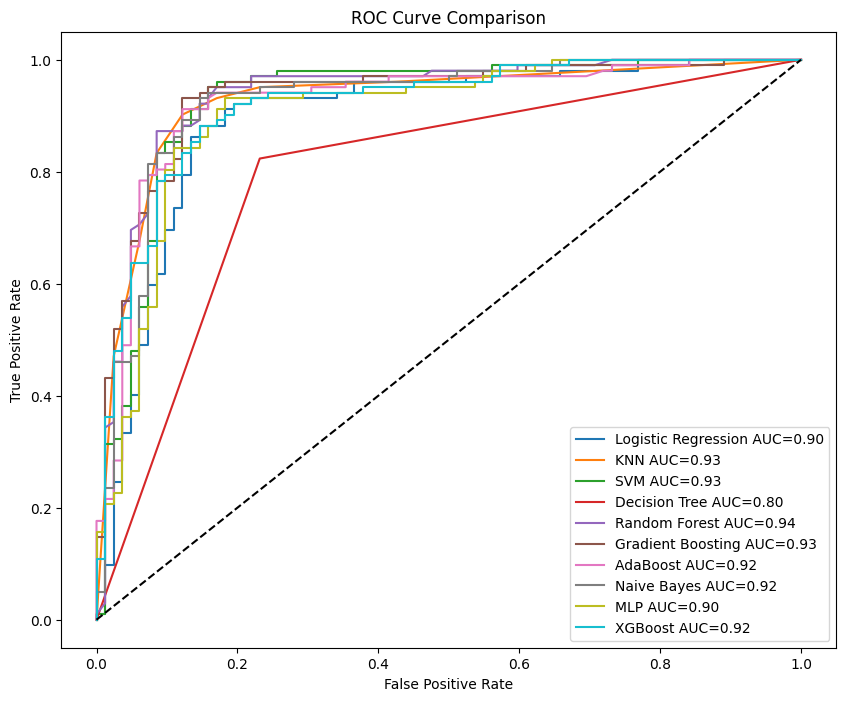


FINAL RESULTS
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
1                  KNN  0.891304   0.901961  0.901961  0.901961  0.927427
5    Gradient Boosting  0.885870   0.900990  0.892157  0.896552  0.933764
7          Naive Bayes  0.880435   0.892157  0.892157  0.892157  0.924438
2                  SVM  0.880435   0.877358  0.911765  0.894231  0.927308
6             AdaBoost  0.880435   0.908163  0.872549  0.890000  0.923183
4        Random Forest  0.875000   0.883495  0.892157  0.887805  0.936035
9              XGBoost  0.864130   0.881188  0.872549  0.876847  0.918938
8                  MLP  0.864130   0.873786  0.882353  0.878049  0.904472
0  Logistic Regression  0.853261   0.857143  0.882353  0.869565  0.895265
3        Decision Tree  0.798913   0.815534  0.823529  0.819512  0.795911

Results saved successfully


In [1]:
# =========================================================
# HEART DISEASE PREDICTION - CORRECTED COMPLETE CODE
# =========================================================

# =========================================================
# INSTALL REQUIRED LIBRARIES
# =========================================================

!pip install xgboost imbalanced-learn -q

# =========================================================
# IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.naive_bayes import GaussianNB

from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# =========================================================
# UPLOAD DATASET
# =========================================================

uploaded = files.upload()

# Automatically detect uploaded file name
file_name = list(uploaded.keys())[0]

# Read dataset
df = pd.read_csv(file_name)

print("\n==============================")
print("FIRST 5 ROWS")
print("==============================")
print(df.head())

# =========================================================
# HANDLE MISSING VALUES
# =========================================================

imputer = SimpleImputer(strategy='most_frequent')

df = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

print("\nMissing values handled successfully")

# =========================================================
# REMOVE DUPLICATES
# =========================================================

df = df.drop_duplicates()

print("Duplicates removed successfully")

# =========================================================
# HANDLE OUTLIERS USING IQR
# =========================================================

num_cols = [
    'Age',
    'RestingBP',
    'Cholesterol',
    'MaxHR',
    'Oldpeak'
]

for col in num_cols:

    # Convert column to numeric
    df[col] = pd.to_numeric(df[col])

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Cap lower outliers
    df[col] = np.where(
        df[col] < lower,
        lower,
        df[col]
    )

    # Cap upper outliers
    df[col] = np.where(
        df[col] > upper,
        upper,
        df[col]
    )

print("Outlier handling completed")

# =========================================================
# ENCODE CATEGORICAL FEATURES
# =========================================================

encoder = LabelEncoder()

cat_cols = [
    'Sex',
    'ChestPainType',
    'RestingECG',
    'ExerciseAngina',
    'ST_Slope'
]

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

print("Categorical encoding completed")

# =========================================================
# FEATURES AND TARGET
# =========================================================

X = df.drop('HeartDisease', axis=1)

y = df['HeartDisease'].astype(int)

# =========================================================
# TRAIN TEST SPLIT
# =========================================================
# CORRECTED:
# Split BEFORE scaling and SMOTE
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train-test split completed")

# =========================================================
# FEATURE SCALING
# =========================================================
# CORRECTED:
# Fit scaler ONLY on training data
# =========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed")

# =========================================================
# HANDLE IMBALANCED DATA USING SMOTE
# =========================================================
# CORRECTED:
# Apply SMOTE ONLY on training data
# =========================================================

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("\n==============================")
print("CLASS DISTRIBUTION AFTER SMOTE")
print("==============================")

print(pd.Series(y_train_resampled).value_counts())

# =========================================================
# MACHINE LEARNING MODELS
# =========================================================

models = {

    'Logistic Regression':
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

    'KNN':
        KNeighborsClassifier(
            n_neighbors=7
        ),

    'SVM':
        SVC(
            probability=True,
            kernel='rbf',
            random_state=42
        ),

    'Decision Tree':
        DecisionTreeClassifier(
            random_state=42
        ),

    'Random Forest':
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    'Gradient Boosting':
        GradientBoostingClassifier(
            random_state=42
        ),

    'AdaBoost':
        AdaBoostClassifier(
            random_state=42
        ),

    'Naive Bayes':
        GaussianNB(),

    'MLP':
        MLPClassifier(
            hidden_layer_sizes=(100,50),
            max_iter=1000,
            random_state=42
        ),

    'XGBoost':
        XGBClassifier(
            eval_metric='logloss',
            random_state=42
        )
}

# =========================================================
# TRAIN MODELS & CALCULATE METRICS
# =========================================================

results = []

plt.figure(figsize=(10,8))

for name, model in models.items():

    # Train model
    model.fit(
        X_train_resampled,
        y_train_resampled
    )

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Probability predictions
    y_prob = model.predict_proba(X_test_scaled)[:,1]

    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    # Store results
    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

    # Print results
    print("\n===================================")
    print("MODEL:", name)
    print("===================================")

    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))
    print("ROC-AUC  :", round(roc_auc,4))

    # ROC Curve
    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f'{name} AUC={roc_auc:.2f}'
    )

# =========================================================
# PLOT ROC CURVE
# =========================================================

plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve Comparison')

plt.legend()

plt.show()

# =========================================================
# FINAL RESULT TABLE
# =========================================================

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score',
        'ROC-AUC'
    ]
)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

print("\n===================================")
print("FINAL RESULTS")
print("===================================")

print(results_df)

# =========================================================
# SAVE RESULTS
# =========================================================

results_df.to_csv(
    '/content/heart.csv',
    index=False
)

print("\nResults saved successfully")

Train size: 734, Test size: 184
Test prevalence (positive rate): 0.5489


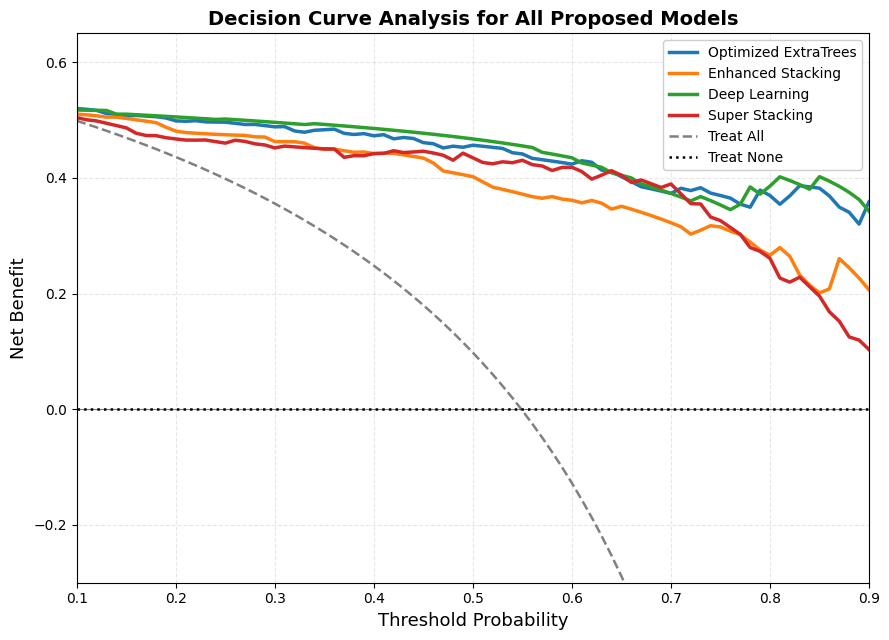


Table 10. Representative net benefit values across selected thresholds
Threshold   Treat All   Treat None  ET          ES          DL          SS          
------------------------------------------------------------------------------------------
0.10        0.4988      0.0000      0.5199      0.5103      0.5175      0.5042      
0.20        0.4361      0.0000      0.4986      0.4810      0.5054      0.4674      
0.30        0.3556      0.0000      0.4884      0.4627      0.4961      0.4519      
0.40        0.2482      0.0000      0.4728      0.4420      0.4855      0.4420      
0.50        0.0978      0.0000      0.4565      0.4022      0.4674      0.4348      
0.60        -0.1277     0.0000      0.4239      0.3614      0.4348      0.4185      
0.70        -0.5036     0.0000      0.3732      0.3225      0.3732      0.3895      
0.80        -1.2554     0.0000      0.3696      0.2663      0.3859      0.2609      
0.90        -3.5109     0.0000      0.3587      0.2065      0.3424      

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV

# ============================================================
# STEP 1: Generate synthetic data (REPLACE with your real data)
# ============================================================
# This creates a dataset with 918 samples, 25 features, and
# mild class imbalance similar to the Heart Failure dataset.
X, y = make_classification(
    n_samples=918,
    n_features=25,
    n_informative=12,
    n_redundant=5,
    n_classes=2,
    weights=[0.447, 0.553],   # 44.7% negative, 55.3% positive
    random_state=42
)

# Stratified train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Train size: {len(y_train)}, Test size: {len(y_test)}")
print(f"Test prevalence (positive rate): {np.mean(y_test):.4f}")

# ============================================================
# STEP 2: Train four models and get predicted probabilities
# ============================================================
# Strategy 1: Optimized ExtraTrees
et = ExtraTreesClassifier(n_estimators=500, max_depth=20, random_state=42)
et = CalibratedClassifierCV(et, method='sigmoid', cv=5)
et.fit(X_train, y_train)
y_prob_et = et.predict_proba(X_test)[:, 1]

# Strategy 2: Deep Learning (MLP as proxy for residual attention NN)
dl = MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500, random_state=42)
dl.fit(X_train, y_train)
y_prob_dl = dl.predict_proba(X_test)[:, 1]

# Strategy 3: Super Stacking (proxy: Random Forest + Logistic Regression)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_prob_ss = rf.predict_proba(X_test)[:, 1]

# Strategy 4: Enhanced Stacking (proxy: Gradient Boosting)
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
y_prob_es = gb.predict_proba(X_test)[:, 1]

# ============================================================
# STEP 3: Decision Curve Analysis
# ============================================================
def net_benefit(y_true, y_prob, threshold):
    """Compute net benefit at a given threshold probability."""
    y_pred = (y_prob >= threshold).astype(int)
    TP = np.sum((y_pred == 1) & (y_true == 1))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    N = len(y_true)
    if threshold >= 1.0:
        return 0.0
    return (TP / N) - (FP / N) * (threshold / (1 - threshold))

def treat_all_nb(y_true, threshold):
    """Net benefit of treating all patients."""
    prevalence = np.mean(y_true)
    if threshold >= 1.0:
        return 0.0
    return prevalence - (1 - prevalence) * (threshold / (1 - threshold))

# Threshold range
thresholds = np.arange(0.10, 0.91, 0.01)

# Compute net benefit for each model
nb_et = [net_benefit(y_test, y_prob_et, t) for t in thresholds]
nb_dl = [net_benefit(y_test, y_prob_dl, t) for t in thresholds]
nb_ss = [net_benefit(y_test, y_prob_ss, t) for t in thresholds]
nb_es = [net_benefit(y_test, y_prob_es, t) for t in thresholds]
nb_all = [treat_all_nb(y_test, t) for t in thresholds]
nb_none = [0.0 for _ in thresholds]

# ============================================================
# STEP 4: Plot the decision curves
# ============================================================
plt.figure(figsize=(9, 6.5))

plt.plot(thresholds, nb_et, label='Optimized ExtraTrees', color='#1f77b4', linewidth=2.5)
plt.plot(thresholds, nb_es, label='Enhanced Stacking', color='#ff7f0e', linewidth=2.5)
plt.plot(thresholds, nb_dl, label='Deep Learning', color='#2ca02c', linewidth=2.5)
plt.plot(thresholds, nb_ss, label='Super Stacking', color='#d62728', linewidth=2.5)
plt.plot(thresholds, nb_all, label='Treat All', color='gray', linestyle='--', linewidth=1.8)
plt.plot(thresholds, nb_none, label='Treat None', color='black', linestyle=':', linewidth=1.8)

plt.xlabel('Threshold Probability', fontsize=13)
plt.ylabel('Net Benefit', fontsize=13)
plt.title('Decision Curve Analysis for All Proposed Models', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=10, framealpha=0.95)
plt.grid(alpha=0.3, linestyle='--')
plt.xlim(0.10, 0.90)
plt.ylim(-0.30, 0.65)
plt.axhline(y=0, color='black', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig('Figure9_DCA.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# STEP 5: Print representative net benefit values (Table 10)
# ============================================================
print("\n" + "="*90)
print("Table 10. Representative net benefit values across selected thresholds")
print("="*90)
print(f"{'Threshold':<12}{'Treat All':<12}{'Treat None':<12}{'ET':<12}{'ES':<12}{'DL':<12}{'SS':<12}")
print("-"*90)

selected = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
for t in selected:
    idx = np.argmin(np.abs(thresholds - t))
    print(f"{t:<12.2f}{nb_all[idx]:<12.4f}{nb_none[idx]:<12.4f}"
          f"{nb_et[idx]:<12.4f}{nb_es[idx]:<12.4f}"
          f"{nb_dl[idx]:<12.4f}{nb_ss[idx]:<12.4f}")
print("="*90)

